<a href="https://colab.research.google.com/github/DawerSP/Inteligencia-Aritificial/blob/main/twitter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
plt.rcParams["figure.figsize"]=(16,9)
plt.style.use("ggplot")

In [3]:
dataframe=pd.read_csv(r"/content/analisis.csv")
dataframe.head()

,usuario,op,co,ex,ag,ne,wordcount,categoria
0,3gerardpique,34.297953,28.148819,41.948819,29.370315,9.841575,37.0945,7
1,aguerosergiokun,44.986842,20.525865,37.938947,24.279098,10.362406,78.7970,7
2,albertochicote,41.733854,13.745417,38.999896,34.645521,8.836979,49.2604,4
3,AlejandroSanz,40.377154,15.377462,52.337538,31.082154,5.032231,80.4538,2
4,alfredocasero1,36.664677,19.642258,48.530806,31.138871,7.305968,47.0645,4


In [8]:
dataframe.groupby("categoria").size()

,0
categoria,
1,27
2,34
3,9
4,19
5,4
6,8
7,17
8,16
9,6


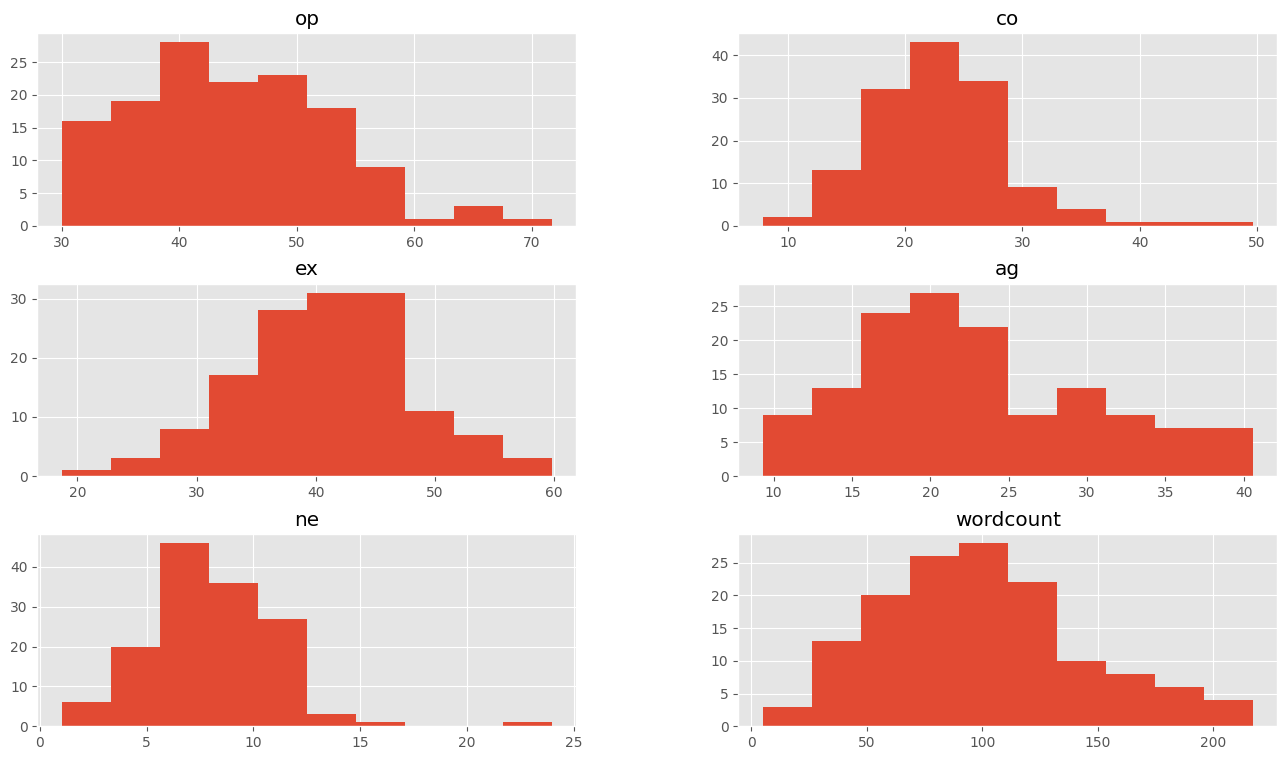

In [4]:
dataframe.drop(columns=["categoria"]).hist()
plt.show()

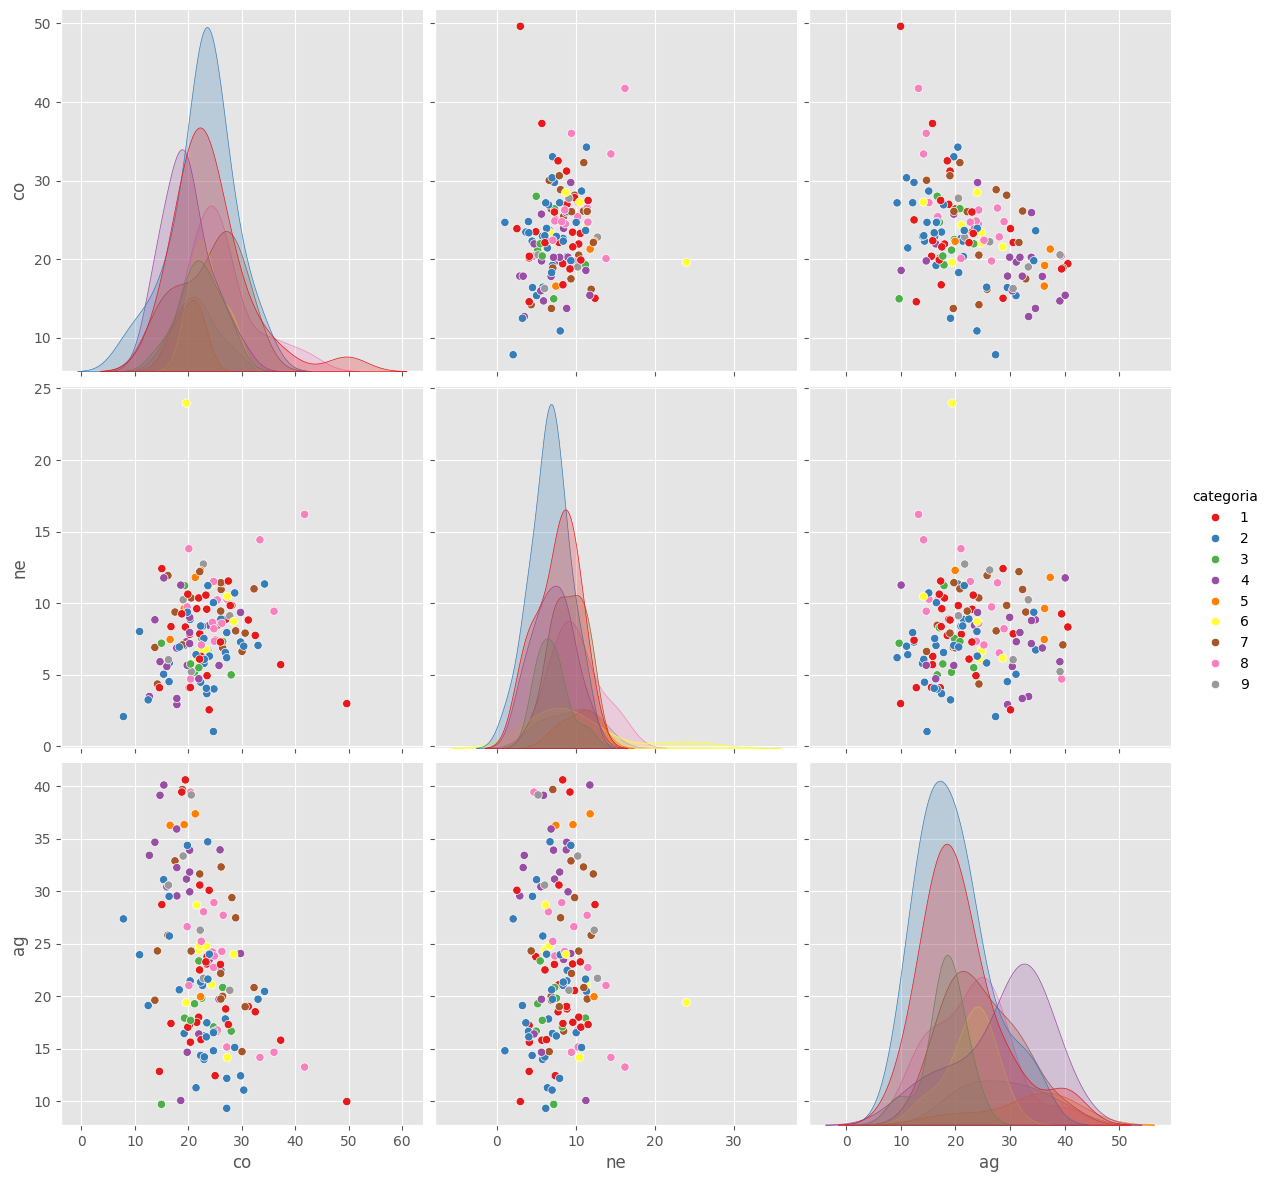

In [10]:
import seaborn as sns


sns.pairplot(
    dataframe.dropna(),
    hue="categoria",
    height=4,
    vars=["co", "ne", "ag"],
    kind="scatter",
    palette="Set1"
)

In [7]:
X=np.array(dataframe[["co","ne","ag"]])
Y=np.array(dataframe["categoria"])
X.shape

(140, 3)

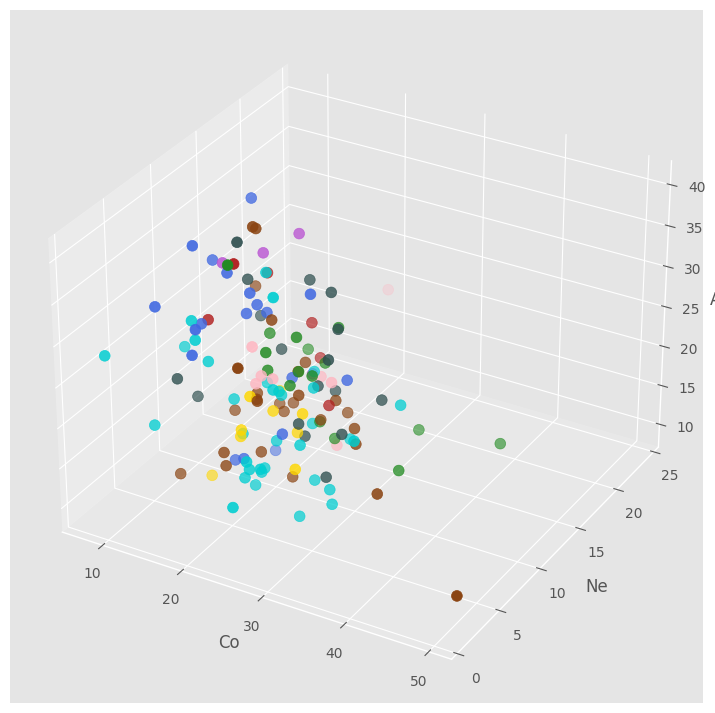

In [11]:
fig=plt.figure()
ax=fig.add_subplot(111,projection="3d")
colores=[
    "#FF4500",
    "#8B4513",
    "darkturquoise",
    "gold",
    "royalblue",
    "mediumorchid",
    "#FFB6C1",
    "darkslategray",
    "forestgreen",
    "firebrick"
]
asignar=[]
for row in Y:
  asignar.append(colores[row])
ax.scatter(X[:,0],X[:,1],X[:,2],c=asignar,s=60)
ax.set_xlabel('Co')
ax.set_ylabel('Ne')
ax.set_zlabel('Ag')
plt.show()

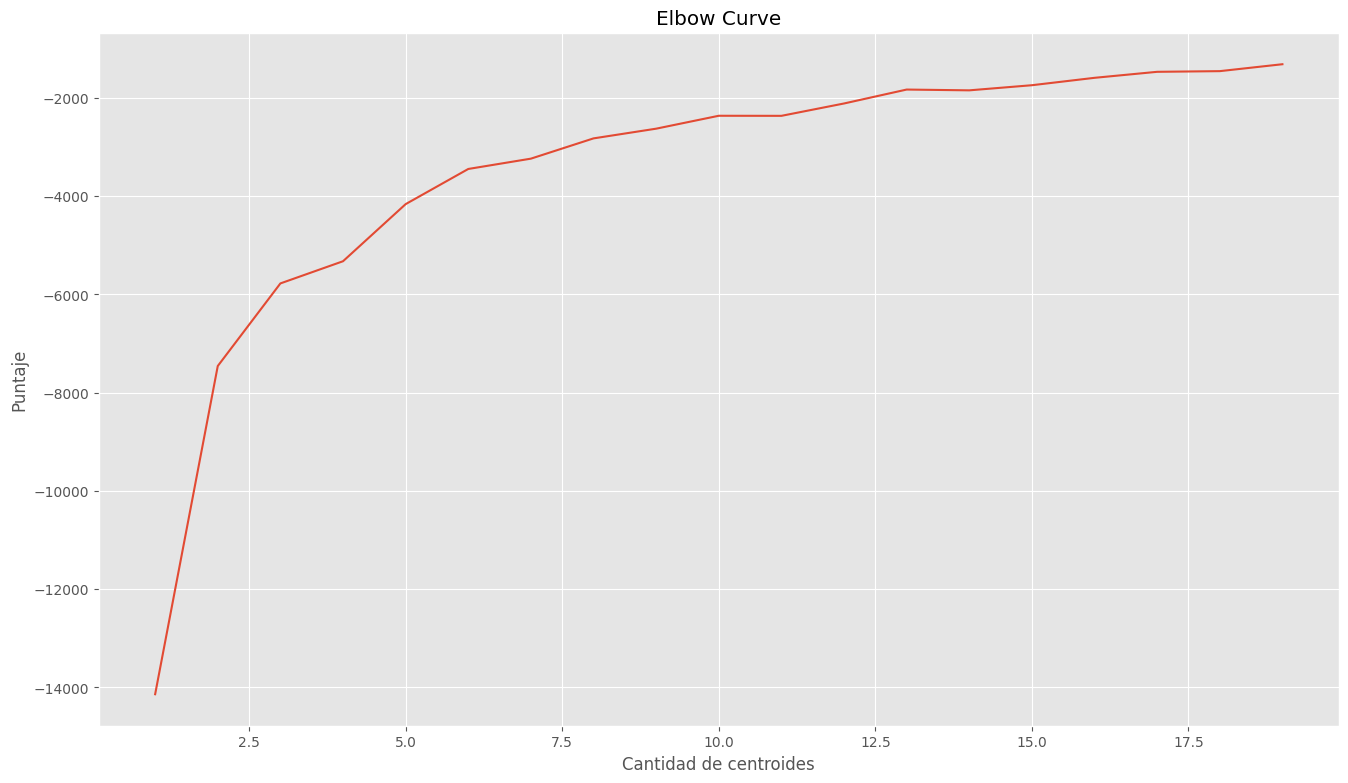

In [12]:
Nc=range(1,20)
kmeans=[KMeans(n_clusters=i) for i in Nc]
kmeans
score=[kmeans[i].fit(X).score(X) for i in range(len(kmeans))]
score
plt.plot(Nc,score)
plt.xlabel("Cantidad de centroides")
plt.ylabel("Puntaje")
plt.title("Elbow Curve")
plt.show()

In [13]:
kmeans=KMeans(n_clusters=5).fit(X)
centroides=kmeans.cluster_centers_
print(centroides)

[[34.06088247  8.94785253 15.89624973]
 [19.01588238  7.52420759 33.89679271]
 [14.1449809   6.1734201  21.6561622 ]
 [24.04566952  9.20971157 23.24068964]
 [23.24017403  7.10841435 15.63533103]]


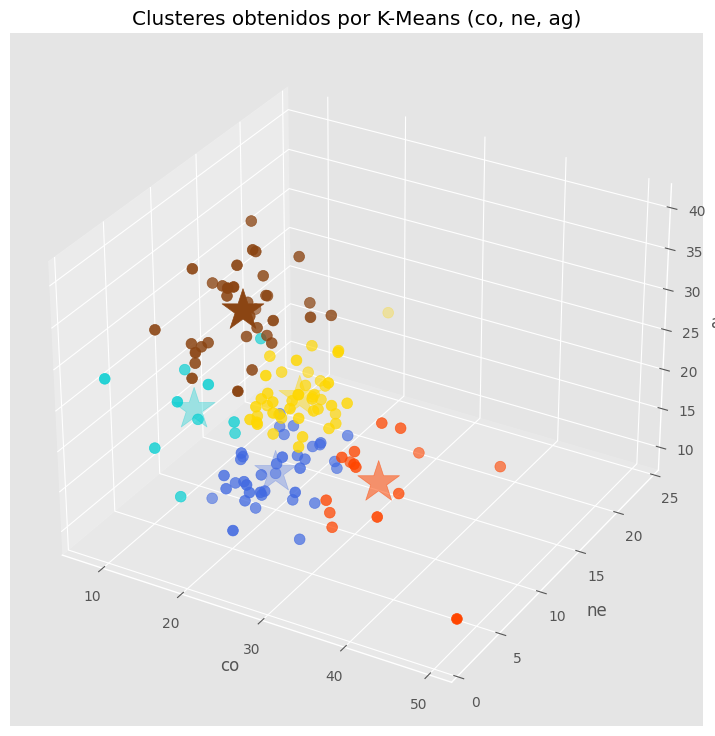

In [16]:
labels = kmeans.predict(X)
C = kmeans.cluster_centers_

colores = [
    "#FF4500",  # Naranja brillante
    "#8B4513",  # Marrón oscuro
    "darkturquoise",
    "gold",
    "royalblue",
]
asignar = []

# (Cambié 'now' por 'label' para que sea más claro)
for label in labels:
    asignar.append(colores[label])

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# Los datos (X[:,0], etc.) están bien si X se definió como en el Prerrequisito
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=asignar, s=60)
ax.scatter(C[:, 0], C[:, 1], C[:, 2], marker="*", color=colores, s=1000)

# --- 🌟 CAMBIOS AQUÍ 🌟 ---

# 1. Cambiar etiqueta Eje X
ax.set_xlabel("co")

# 2. Cambiar etiqueta Eje Y
ax.set_ylabel("ne")

# 3. Cambiar etiqueta Eje Z
ax.set_zlabel("ag")

# 4. Cambiar Título
ax.set_title("Clusteres obtenidos por K-Means (co, ne, ag)")

plt.show()

Text(0.5, 1.0, 'co vs ne')

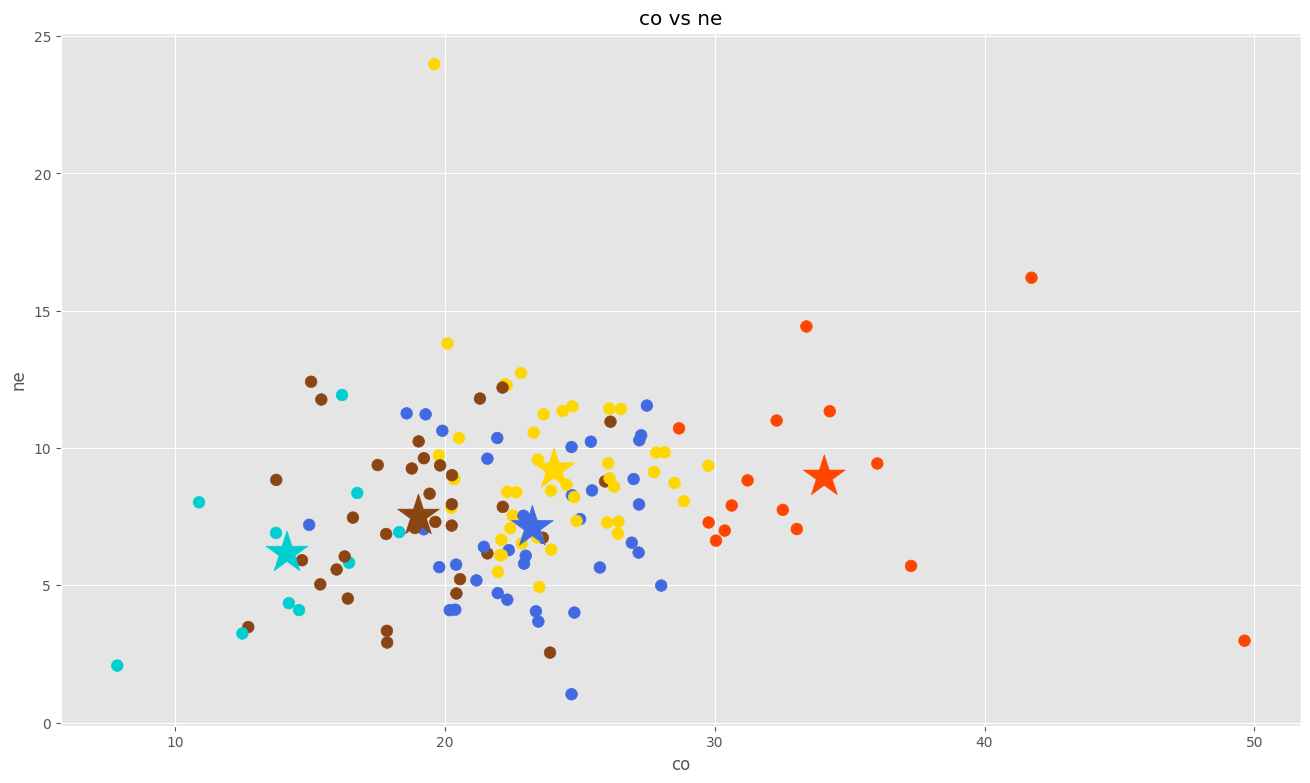

In [17]:
# --- 🌟 CAMBIOS AQUÍ 🌟 ---
# f1 ahora es "co" (eje X)
f1 = dataframe["co"].values
# f2 ahora es "ne" (eje Y)
f2 = dataframe["ne"].values
# ---------------------------

plt.scatter(f1, f2, c=asignar, s=70)
plt.scatter(C[:, 0], C[:, 1], marker="*", c=colores, s=1000)

# --- 🌟 CAMBIO DE ETIQUETAS Y TÍTULO 🌟 ---
plt.xlabel("co")
plt.ylabel("ne")
plt.title("co vs ne")
# ---------------------------------------------

In [18]:
copy=pd.DataFrame()
copy["usuario"]=dataframe["usuario"].values
copy["categoria"]=dataframe["categoria"].values
copy["label"]=labels;
cantidadGrupo=pd.DataFrame()
cantidadGrupo["Color"]=colores
cantidadGrupo["cantidad"]=copy.groupby("label").size()
cantidadGrupo

,Color,cantidad
0,#FF4500,15
1,#8B4513,34
2,darkturquoise,10
3,gold,44
4,royalblue,37


In [19]:
group_referrer_index=copy["label"]==0
group_referrals=copy[group_referrer_index]

diversidadGrupo=pd.DataFrame()
diversidadGrupo["categoria"]=[0,1,2,3,4,5,6,7,8,9]
diversidadGrupo["cantidad"]=group_referrals.groupby("categoria").size()
diversidadGrupo

,categoria,cantidad
0,0,NaN
1,1,4.0
2,2,5.0
3,3,NaN
4,4,NaN
5,5,NaN
6,6,NaN
7,7,3.0
8,8,3.0
9,9,NaN


In [20]:
closest,_= pairwise_distances_argmin_min(kmeans.cluster_centers_,X)
closest

array([ 71, 118,   6,  56,  75])

In [21]:
user=dataframe["usuario"].values
for row in closest:
  print(user[row])

jiminhofe
ristomejide
andresiniesta8
GwynethPaltrow
JLo


In [22]:
X_new=np.array([[45.92,57.74,15.66]])

new_labels=kmeans.predict(X_new)
print(new_labels)

[0]


Calculando puntajes de Silueta para cada 'k'...
Para k=2, el puntaje de silueta es: 0.4313
Para k=3, el puntaje de silueta es: 0.3225
Para k=4, el puntaje de silueta es: 0.3223
Para k=5, el puntaje de silueta es: 0.3013
Para k=6, el puntaje de silueta es: 0.2986
Para k=7, el puntaje de silueta es: 0.2886
Para k=8, el puntaje de silueta es: 0.2859
Para k=9, el puntaje de silueta es: 0.2809
Para k=10, el puntaje de silueta es: 0.2805
---
El 'k' óptimo (con el puntaje de silueta más alto) es: **2**
Puntaje de silueta más alto: 0.4313


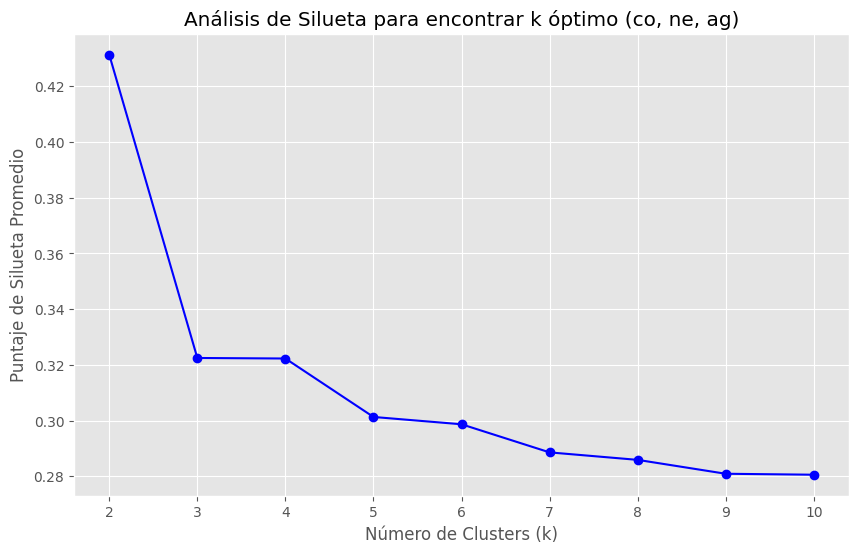

In [25]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# 1. Cargar y preparar los datos
try:
    dataframe = pd.read_csv("analisis.csv")

    # --- 🌟 LÍNEA MODIFICADA 🌟 ---
    # X ahora se basa en 'co', 'ne', y 'ag'
    X = dataframe[["co", "ne", "ag"]].values

except FileNotFoundError:
    print("Error: No se encontró el archivo 'analisis.csv'")
except KeyError as e:
    # Capturamos la llave del error para un mensaje más útil
    print(f"Error: La columna {e} no existe. Asegúrate de que las columnas 'co', 'ne', y 'ag' existan en tu CSV.")

# -------------------------------------------------------------

# --- Aquí empieza el análisis de Silueta ---

# Definimos el rango de 'k' que queremos probar
k_range = range(2, 11)

# Lista para guardar los puntajes de silueta para cada k
silhouette_scores = []

print("Calculando puntajes de Silueta para cada 'k'...")

for k in k_range:
    # 1. Crear y ajustar el modelo K-Means para 'k' clusters
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_model.fit_predict(X)

    # 2. Calcular el puntaje de silueta promedio
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

    print(f"Para k={k}, el puntaje de silueta es: {score:.4f}")

# -------------------------------------------------------------

# --- Encontrar el mejor 'k' ---
if silhouette_scores:
    best_k = k_range[silhouette_scores.index(max(silhouette_scores))]
    print("---")
    print(f"El 'k' óptimo (con el puntaje de silueta más alto) es: **{best_k}**")
    print(f"Puntaje de silueta más alto: {max(silhouette_scores):.4f}")
else:
    print("No se pudieron calcular los puntajes de silueta.")

# -------------------------------------------------------------

# --- Graficar los resultados ---
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Puntaje de Silueta Promedio')
plt.title('Análisis de Silueta para encontrar k óptimo (co, ne, ag)') # Título actualizado
plt.xticks(k_range)
plt.grid(True)
plt.show()

Calculando puntajes Calinski-Harabasz para cada 'k'...
Para k=2, el puntaje Calinski-Harabasz es: 123.6620
Para k=3, el puntaje Calinski-Harabasz es: 99.6173
Para k=4, el puntaje Calinski-Harabasz es: 95.5117
Para k=5, el puntaje Calinski-Harabasz es: 87.7263
Para k=6, el puntaje Calinski-Harabasz es: 82.7521
Para k=7, el puntaje Calinski-Harabasz es: 78.4195
Para k=8, el puntaje Calinski-Harabasz es: 75.7707
Para k=9, el puntaje Calinski-Harabasz es: 72.9641
Para k=10, el puntaje Calinski-Harabasz es: 73.7777
---
El 'k' óptimo (con el puntaje CH más alto) es: **2**
Puntaje CH más alto: 123.6620


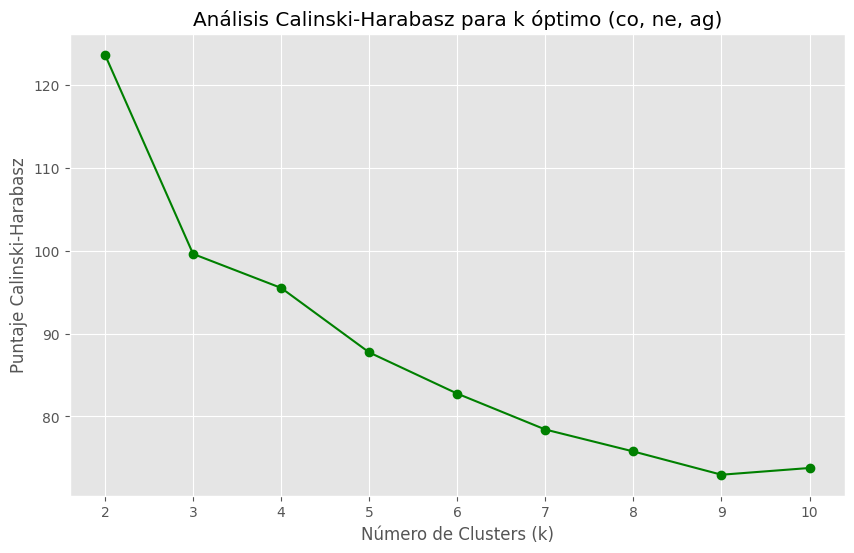

In [26]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score # <-- ¡Cambiamos la métrica!
import matplotlib.pyplot as plt

# 1. Cargar y preparar los datos
try:
    dataframe = pd.read_csv("analisis.csv")

    # --- 🌟 LÍNEA MODIFICADA 🌟 ---
    # X ahora se basa en 'co', 'ne', y 'ag'
    X = dataframe[["co", "ne", "ag"]].values

except FileNotFoundError:
    print("Error: No se encontró el archivo 'analisis.csv'")
    # Salir o manejar el error
except KeyError as e:
    # Capturamos la llave del error para un mensaje más útil
    print(f"Error: La columna {e} no existe. Asegúrate de que las columnas 'co', 'ne', y 'ag' existan en tu CSV.")
    # Salir o manejar el error

# --------------------------------------------------------------------------------------

# --- Aquí empieza el análisis Calinski-Harabasz ---

# Definimos el rango de 'k' que queremos probar
k_range = range(2, 11)

# Lista para guardar los puntajes CH para cada k
ch_scores = []

print("Calculando puntajes Calinski-Harabasz para cada 'k'...")

for k in k_range:
    # 1. Crear y ajustar el modelo K-Means para 'k' clusters
    kmeans_model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_model.fit_predict(X)

    # 2. Calcular el puntaje Calinski-Harabasz
    score = calinski_harabasz_score(X, labels)
    ch_scores.append(score)

    print(f"Para k={k}, el puntaje Calinski-Harabasz es: {score:.4f}")

# --- Encontrar el mejor 'k' ---
best_k = k_range[ch_scores.index(max(ch_scores))]
print("---")
print(f"El 'k' óptimo (con el puntaje CH más alto) es: **{best_k}**")
print(f"Puntaje CH más alto: {max(ch_scores):.4f}")

# --------------------------------------------------------------------------------------

# --- Graficar los resultados ---
plt.figure(figsize=(10, 6))
plt.plot(k_range, ch_scores, 'go-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Puntaje Calinski-Harabasz')
plt.title('Análisis Calinski-Harabasz para k óptimo (co, ne, ag)') # Título actualizado
plt.xticks(k_range)
plt.grid(True)
plt.show()